# Sentiment Analysis — Synthetic vs. Real Data Comparison

Compares the GET pipeline's synthetic data against real tweet_eval samples.
- **Real**: tweets from `tweet_eval/sentiment` (NEGATIVE=0, NEUTRAL=1, POSITIVE=2)
- **Synthetic**: generated by the pipeline, stored in `framework/data/runs/sentiment/`

**Hypothesis**: If models score higher on real data than on synthetic data, this suggests data leakage.

## Setup

In [21]:
import sys, os, json, glob
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

project_root = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Project root: {project_root}")

Project root: c:\Users\nikla\Dokumente\Master\FSS2026_lokal\live-eval


## Load Synthetic Data
Picks the latest session from `framework/data/runs/sentiment/`.

In [22]:
runs_dir = os.path.join(project_root, "framework", "data", "runs", "sentiment")

sessions = sorted(glob.glob(os.path.join(runs_dir, "*")), reverse=True)
if not sessions:
    raise FileNotFoundError(f"No sessions found in {runs_dir}. Run the pipeline first.")

latest_session = sessions[0]
print(f"Using session: {os.path.basename(latest_session)}")

run_files = sorted(glob.glob(os.path.join(latest_session, "generated", "run_*.json")))
if not run_files:
    run_files = sorted(glob.glob(os.path.join(runs_dir, "*_run*.json")))

synthetic = []
for path in run_files:
    with open(path, encoding="utf-8") as f:
        synthetic.extend(json.load(f))

print(f"Loaded {len(synthetic)} synthetic samples from {len(run_files)} run(s).")

Using session: 20260723_151906
Loaded 30 synthetic samples from 1 run(s).


## Load Real Data

In [23]:
from datasets import load_dataset

LABEL_MAP = {0: "NEGATIVE", 1: "NEUTRAL", 2: "POSITIVE"}
N_REAL = len(synthetic) if synthetic else 150

print(f"Loading {N_REAL} real samples from tweet_eval/sentiment ...")
ds = load_dataset("tweet_eval", "sentiment", split="train", streaming=True)

real = []
for row in ds:
    real.append({"text": row["text"], "label": LABEL_MAP[row["label"]]})
    if len(real) >= N_REAL:
        break

print(f"Loaded {len(real)} real samples.")

Loading 30 real samples from tweet_eval/sentiment ...
Loaded 30 real samples.


## Load Models

In [24]:
from framework.models.sentiment.transformer import TransformerSentimentModel

BERTWEET_CONFIG = {
    "name": "finiteautomata/bertweet-base-sentiment-analysis",
    "type": "bertweet",
    "max_length": 128,
    "label_map": {"POS": "POSITIVE", "NEU": "NEUTRAL", "NEG": "NEGATIVE"}
}
MULTILINGUAL_CONFIG = {
    "name": "tabularisai/multilingual-sentiment-analysis",
    "type": "multilingual",
    "max_length": 256,
    "label_map": {
        "Very Positive": "POSITIVE", "Positive": "POSITIVE",
        "Neutral": "NEUTRAL",
        "Negative": "NEGATIVE", "Very Negative": "NEGATIVE"
    }
}

print("Loading models...")
bertweet      = TransformerSentimentModel(BERTWEET_CONFIG)
multilingual  = TransformerSentimentModel(MULTILINGUAL_CONFIG)
print("All models loaded.")

Loading models...
Loading model: finiteautomata/bertweet-base-sentiment-analysis ...


emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 18380.03it/s]
RobertaForSequenceClassification LOAD REPORT from: finiteautomata/bertweet-base-sentiment-analysis
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded finiteautomata/bertweet-base-sentiment-analysis.
Loading model: tabularisai/multilingual-sentiment-analysis ...


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 5859.30it/s]

Loaded tabularisai/multilingual-sentiment-analysis.
All models loaded.


## Static Evaluation (Real Data)
Evaluate both models directly on the real tweet_eval samples.

In [25]:
from framework.evaluators.classification.accuracy import compute_accuracy

def evaluate_model(model, samples):
    texts = [s["text"] for s in samples]
    preds = model.predict(texts)
    results = [{"prediction": p, "label": s["label"]} for p, s in zip(preds, samples)]
    return {"accuracy": compute_accuracy(results)}

print("Evaluating on real data...")
real_bertweet     = evaluate_model(bertweet,     real)
real_multilingual = evaluate_model(multilingual, real)
print(f"  bertweet:     {real_bertweet}")
print(f"  multilingual: {real_multilingual}")

Evaluating on real data...
  bertweet:     {'accuracy': 0.8333333333333334}
  multilingual: {'accuracy': 0.4666666666666667}


## Synthetic Evaluation Results
Load accuracy scores from the pipeline results.json.

In [26]:
results_path = os.path.join(latest_session, "results.json")
with open(results_path, encoding="utf-8") as f:
    pipeline_results = json.load(f)

scores = pipeline_results.get("results", pipeline_results)

BERTWEET_KEY     = "finiteautomata/bertweet-base-sentiment-analysis"
MULTILINGUAL_KEY = "tabularisai/multilingual-sentiment-analysis"

def get_mean(scores, model_key, metric):
    # structure: results → model → generated → metric → {mean, std}
    val = scores.get(model_key, {}).get("generated", {}).get(metric, {})
    if isinstance(val, dict):
        return val.get("mean", 0.0)
    return val

synth_bertweet     = {"accuracy": get_mean(scores, BERTWEET_KEY,     "accuracy")}
synth_multilingual = {"accuracy": get_mean(scores, MULTILINGUAL_KEY, "accuracy")}

print(f"Synthetic — bertweet:     {synth_bertweet}")
print(f"Synthetic — multilingual: {synth_multilingual}")

Synthetic — bertweet:     {'accuracy': 0.8519}
Synthetic — multilingual: {'accuracy': 0.7037}


## Model Comparison — Real vs. Synthetic

          bertweet (real)  bertweet (synthetic)  multilingual (real)  multilingual (synthetic)
accuracy           0.8333                0.8519               0.4667                    0.7037


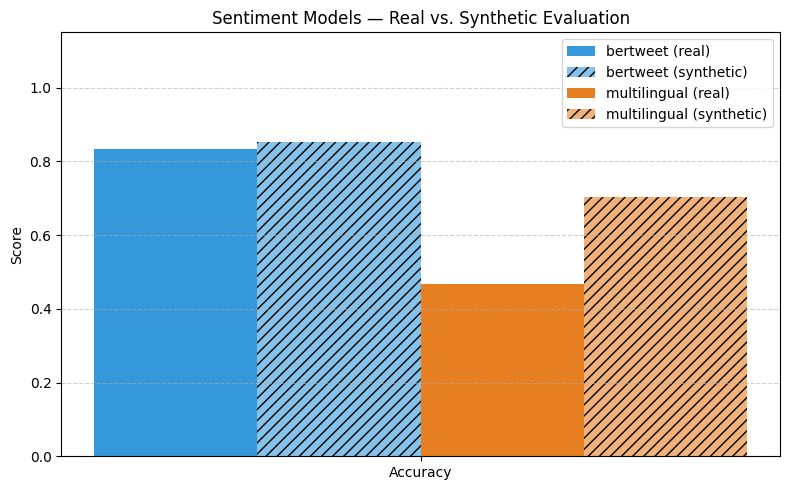

In [27]:
metrics = ["accuracy"]

df = pd.DataFrame({
    "bertweet (real)": [real_bertweet[m] for m in metrics],
    "bertweet (synthetic)": [synth_bertweet[m] for m in metrics],
    "multilingual (real)": [real_multilingual[m] for m in metrics],
    "multilingual (synthetic)": [synth_multilingual[m] for m in metrics],
}, index=metrics)
print(df.round(4).to_string())

x = np.arange(len(metrics))
width = 0.2
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - 1.5*width, [real_bertweet[m]        for m in metrics], width, label="bertweet (real)",         color="#3498db")
ax.bar(x - 0.5*width, [synth_bertweet[m]       for m in metrics], width, label="bertweet (synthetic)",    color="#3498db", hatch="///", alpha=0.6)
ax.bar(x + 0.5*width, [real_multilingual[m]    for m in metrics], width, label="multilingual (real)",     color="#e67e22")
ax.bar(x + 1.5*width, [synth_multilingual[m]   for m in metrics], width, label="multilingual (synthetic)",color="#e67e22", hatch="///", alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in metrics])
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Sentiment Models — Real vs. Synthetic Evaluation")
ax.legend()
ax.yaxis.grid(True, linestyle="--", alpha=0.6)
fig.tight_layout()
plt.savefig("sentiment_synthetic_vs_real.png", dpi=150)
plt.show()

## Label Distribution — Real vs. Synthetic

           Real  Synthetic
NEGATIVE  0.100      0.815
NEUTRAL   0.533      0.037
POSITIVE  0.367      0.148


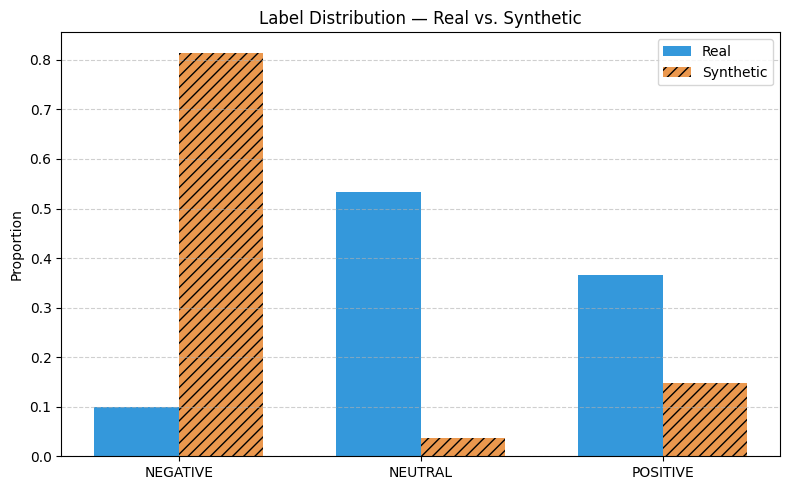

In [28]:
real_counts = Counter(r["label"] for r in real)

def synth_label(item):
    et = item.get("error_type", "")
    if "negative" in et or et in ("sarcasm_injection", "negation_insertion"):
        return "NEGATIVE"
    if "positive" in et:
        return "POSITIVE"
    if et == "intensity_reduction":
        return "NEUTRAL"
    return "OTHER"

synth_counts = Counter(synth_label(s) for s in synthetic)

labels = ["NEGATIVE", "NEUTRAL", "POSITIVE"]
real_vals  = [real_counts.get(l, 0) for l in labels]
synth_vals = [synth_counts.get(l, 0) for l in labels]
real_props  = [v / max(sum(real_vals), 1)  for v in real_vals]
synth_props = [v / max(sum(synth_vals), 1) for v in synth_vals]

df_dist = pd.DataFrame({"Real": real_props, "Synthetic": synth_props}, index=labels)
print(df_dist.round(3).to_string())

x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, real_props,  width, label="Real",      color="#3498db")
ax.bar(x + width/2, synth_props, width, label="Synthetic", color="#e67e22", hatch="///", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Proportion")
ax.set_title("Label Distribution — Real vs. Synthetic")
ax.legend()
ax.yaxis.grid(True, linestyle="--", alpha=0.6)
fig.tight_layout()
plt.savefig("sentiment_label_dist.png", dpi=150)
plt.show()

## Error Type Breakdown (Synthetic)

             error_type  count
sentiment_flip_negative     20
sentiment_flip_positive      4
             paraphrase      3
      sarcasm_injection      2
    intensity_reduction      1


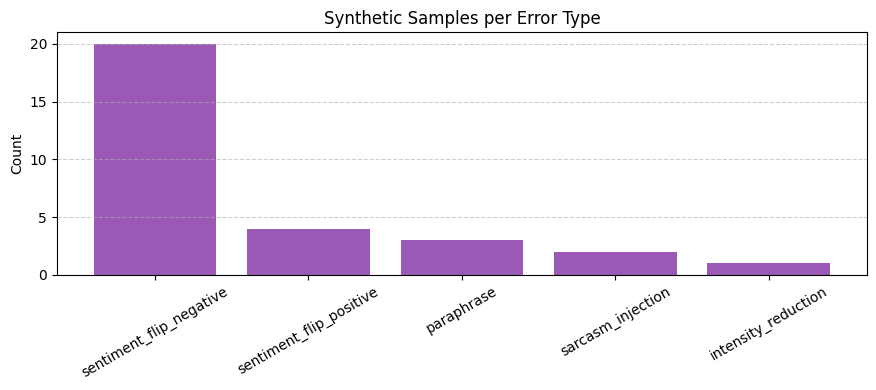

In [29]:
error_counts = Counter(s.get("error_type", "unknown") for s in synthetic)
error_df = pd.DataFrame(error_counts.most_common(), columns=["error_type", "count"])
print(error_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(error_df["error_type"], error_df["count"], color="#9b59b6")
ax.set_ylabel("Count")
ax.set_title("Synthetic Samples per Error Type")
ax.tick_params(axis="x", rotation=30)
ax.yaxis.grid(True, linestyle="--", alpha=0.6)
fig.tight_layout()
plt.savefig("sentiment_error_types.png", dpi=150)
plt.show()

## Text Length Distribution

Real      — mean: 18.6 words, median: 19.0
Synthetic — mean: 22.2 words, median: 22.0


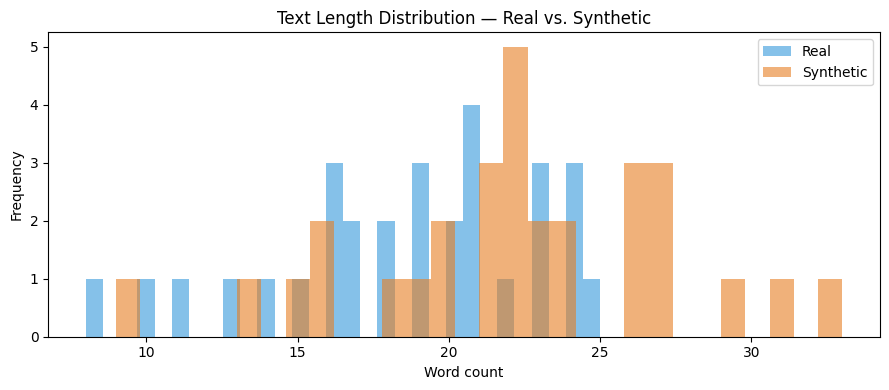

In [30]:
real_lengths  = [len(r["text"].split()) for r in real]
synth_lengths = [len(s["corrupted"].split()) for s in synthetic]

print(f"Real      — mean: {np.mean(real_lengths):.1f} words, median: {np.median(real_lengths):.1f}")
print(f"Synthetic — mean: {np.mean(synth_lengths):.1f} words, median: {np.median(synth_lengths):.1f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(real_lengths,  bins=30, alpha=0.6, label="Real",      color="#3498db")
ax.hist(synth_lengths, bins=30, alpha=0.6, label="Synthetic", color="#e67e22")
ax.set_xlabel("Word count")
ax.set_ylabel("Frequency")
ax.set_title("Text Length Distribution — Real vs. Synthetic")
ax.legend()
fig.tight_layout()
plt.savefig("sentiment_length_dist.png", dpi=150)
plt.show()

## Sample Examples

In [31]:
print("=== REAL SAMPLES ===")
for r in real[:5]:
    print(f"[{r['label']}] {r['text'][:120]}")

print("\n=== SYNTHETIC SAMPLES ===")
for s in synthetic[:5]:
    print(f"[{s.get('error_type')}]")
    print(f"  original : {s.get('original', '')[:100]}")
    print(f"  corrupted: {s.get('corrupted', '')[:100]}")

=== REAL SAMPLES ===
[POSITIVE] "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
[NEUTRAL] "Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"
[NEUTRAL] Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow ni
[NEUTRAL] Chase Headley's RBI double in the 8th inning off David Price snapped a Yankees streak of 33 consecutive scoreless inning
[POSITIVE] @user Alciato: Bee will invest 150 million in January, another 200 in the Summer and plans to bring Messi by 2017"

=== SYNTHETIC SAMPLES ===
[sentiment_flip_negative]
  original : "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #Happy
  corrupted: QT @user In the original draft of the 7th book, Remus Lupin was tragically killed off in the Battle 
[sentiment_flip_negative]
  original : "Ben Smith / Smith (concussion) remains out o